# SL2S kinematic sample
This notebook compiles data from lenses with imaging data and integrated velocity dispersion measurements from SL2S.

In [1]:
from hierarc.LensPosterior.kin_constraints import KinConstraints
from hierarc.Util import ifu_util
from lenstronomy.Util import constants as const
from lenstronomy.Util import param_util
from astropy.io import fits
import numpy as np
import pickle
import os
import csv
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
from copy import deepcopy
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.Analysis.light_profile import LightProfileAnalysis

## Sample from SL2S

The lens model parameters are being taken from [Sheu et al. 2024](https://ui.adsabs.harvard.edu/abs/2024arXiv240810316S/abstract), with those lenses not included in the Sheu et al. sample taken by [Tan et al. 2023](https://ui.adsabs.harvard.edu/abs/2024MNRAS.530.1474T/abstract) based on shallower HST data. 


In [2]:
dir_path = os.getcwd()


# numerical settings (not needed if power-law profiles with Hernquist light distribution is computed)
kwargs_numerics_galkin = {'interpol_grid_num': 1000,  # numerical interpolation, should converge -> infinity
                          'log_integration': True,  # log or linear interpolation of surface brightness and mass models
                          'max_integrate': 100, 'min_integrate': 0.001}  # lower/upper bound of numerical integrals

num_sample_model_slit = 100  # number of draws from the model to generate a kinematic prediction for the slit data

# anisotropy model
anisotropy_model = 'const' # 'OM', 'GOM', 'const

# population distribution in the power-law slope
# this distribution is assumed on lenses within the sample that do not have a reliably measured slope from imaging data


# file containing all the information about the sample including lens model parameters from imaging data
file_name_param_catalogue = 'sl2s_all_params.csv' 
file_name_param = os.path.join(dir_path, file_name_param_catalogue)
print(file_name_param)

# Updated lens model parameters from Sheu et al. 2024

file_name_param_catalogue_ws = 'sl2s_all_params_ws.csv' 
file_name_param_ws = os.path.join(dir_path, file_name_param_catalogue_ws)
print(file_name_param_ws)

process_slit = False
process_slit_ws = False


/Users/xiangyuhuang/Documents/phd_research/TDCOSMO_milestone/7LensMilestone/Likelihoods/MilestoneLikelihood/ExternalLenses/SL2S/sl2s_all_params.csv
/Users/xiangyuhuang/Documents/phd_research/TDCOSMO_milestone/7LensMilestone/Likelihoods/MilestoneLikelihood/ExternalLenses/SL2S/sl2s_all_params_ws.csv


gamma_error_sys reduce factor = 0.7643889482095422


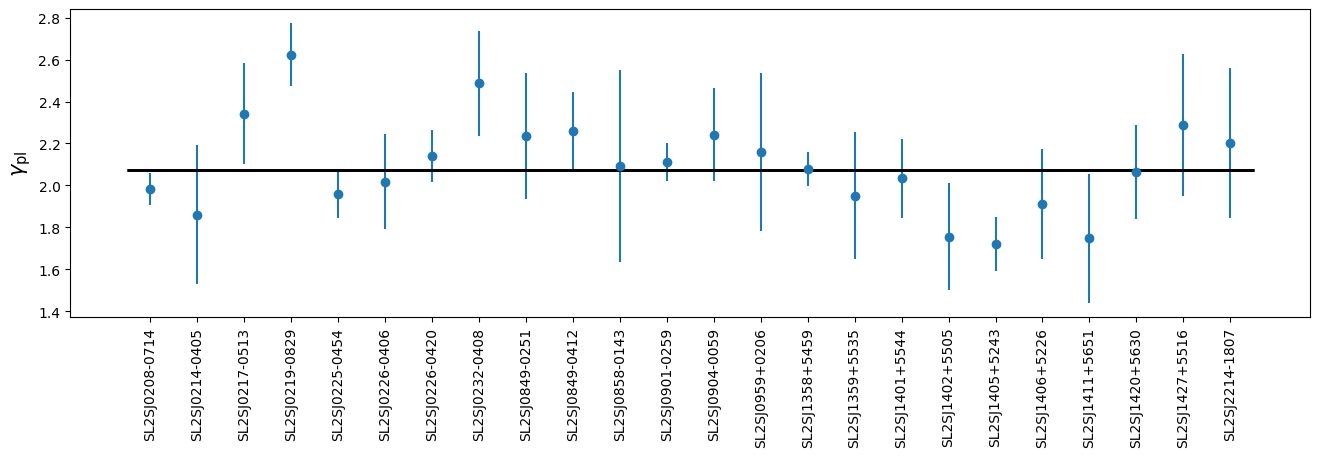

Mean of population gamma: 2.0716964073330346
Expected scatter in gamma (if nan, no scatter expected) nan


In [3]:
# Compute population level power-law slopes and spread

def gamma_pop(file_name):
    """
    estimates the population mean and Gaussian spread of the power-law slope based on lensing data only
    """
    gamma_list = []
    # gamma_error_list = []
    gamma_error_stat_list = []
    gamma_error_sys_list = []
    name_list_gamma = []

    with open(file_name, newline='') as myFile:
        reader = csv.DictReader(myFile)
        for row in reader:
            name = row['name']
            try:
                flag_imaging = float(row['flag_modelled'])
            except:
                flag_imaging = float(row['flag_imaging_tan23'])  # TODO: change that to the same convention as SLACS
            if flag_imaging == 1:
                if True:  
                    gamma_error_sys = float(row['gamma_error_sys'])
                    gamma_error_stat = float(row['gamma_error_stat'])
                    gamma_error_sys_list.append(gamma_error_sys)
                    gamma_error_stat_list.append(gamma_error_stat)
                    # gamma_error = np.hypot(gamma_error_sys, gamma_error_stat) # eq.(11) in Tan et al 2024
                    # gamma_error_list.append(gamma_error)
                    gamma = float(row['gamma'])
                    gamma_list.append(gamma)
                    name_list_gamma.append(name)
    gamma_list = np.array(gamma_list)
    gamma_error_stat_list = np.array(gamma_error_stat_list)
    gamma_error_sys_list = np.array(gamma_error_sys_list)
    gamma_error_list = np.hypot(gamma_error_stat_list, gamma_error_sys_list)
    gamma_mean_pop = np.average(gamma_list, weights=1./ gamma_error_list**2)
    error_var = np.mean(gamma_error_list**2)  # square average error in the measurement
    if np.var(gamma_list) >= error_var:
        gamma_sigma_pop = np.sqrt(np.var(gamma_list) - error_var)  # subtract the error variance from the measured variance
    else:
        gamma_sigma_pop = float('nan')
        gamma_error_reduce_factor = np.sqrt((np.var(gamma_list) - np.average(gamma_error_stat_list**2)) / np.average(gamma_error_sys_list**2))
        print('gamma_error_sys reduce factor = {}' .format(gamma_error_reduce_factor))
        
    
    # make plot of distribution
    f, ax = plt.subplots(1, 1, figsize=(len(name_list_gamma)/1.5, 4))
    x = np.arange(len(name_list_gamma))
    ax.errorbar(x, gamma_list, yerr=gamma_error_list,
                    #color=color_measurement,
                    xerr=None, fmt='o', ecolor=None, elinewidth=None,
                    capsize=None, barsabove=False, lolims=False, uplims=False,
                    xlolims=False, xuplims=False, errorevery=1, capthick=None, data=None)

    ax.hlines(y=gamma_mean_pop, xmin=-0.5, xmax=len(name_list_gamma)-0.5, linewidth=2, color='k')
    ax.hlines(y=gamma_mean_pop - gamma_sigma_pop, xmin=-0.5, xmax=len(name_list_gamma)-0.5, linestyle='--', linewidth=2, color='k')
    ax.hlines(y=gamma_mean_pop + gamma_sigma_pop, xmin=-0.5, xmax=len(name_list_gamma)-0.5, linestyle='--', linewidth=2, color='k')
    ax.hlines(y=gamma_mean_pop, xmin=-0.5, xmax=len(name_list_gamma)-0.5, linewidth=2, color='k')
    ax.set_xticks(ticks=x)
    ax.set_xticklabels(labels=name_list_gamma, rotation='vertical')
    ax.set_ylabel(r'$\gamma_{\rm pl}$', fontsize=15)
    plt.show()
    
    return gamma_mean_pop, gamma_sigma_pop

gamma_mean_pop, gamma_error_pop = gamma_pop(file_name=file_name_param)

print('Mean of population gamma:', gamma_mean_pop)
print('Expected scatter in gamma (if nan, no scatter expected)' , gamma_error_pop)

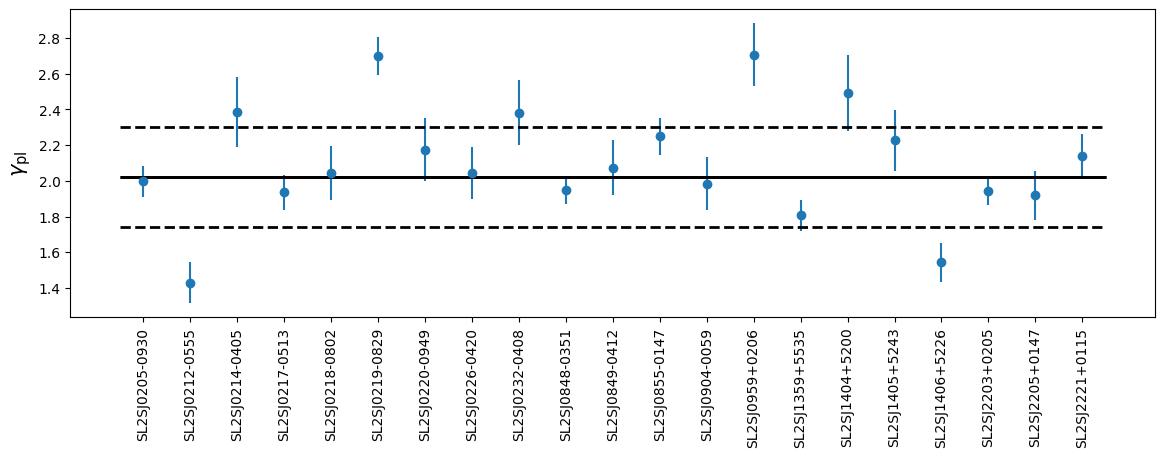

Mean of population gamma: 2.0220894454570617
Expected scatter in gamma (if nan, no scatter expected) 0.2804617958517462


In [4]:
gamma_mean_pop_ws, gamma_error_pop_ws = gamma_pop(file_name=file_name_param_ws)

print('Mean of population gamma:', gamma_mean_pop_ws)
print('Expected scatter in gamma (if nan, no scatter expected)' , gamma_error_pop_ws)

For full comparison of gamma_pl of the SL2S lens sample, see sample_selection.ipynb

In [5]:
def check_data(row):
    """
    check whether all necessary data properties are available
    """
    try:
        _test = float(row['flag_modelled'])
        _test = float(row['z_lens'])
        _test = float(row['z_source'])
        _test = float(row['sigma_v_pritom'])
        return True
    except:
        try:
            _test = float(row['flag_imaging_tan23'])
            _test = float(row['z_lens'])
            _test = float(row['z_source'])
            _test = float(row['sigma_v_pritom'])
            return True
        except:
            return False
    
def light_ellipticity(row):
    """
    computes the light ellipticity from the raw in the table. This function can deal with single and double Sersic profiles
    """
    try:
        light_model = str(row['light_model'])
        add = ''
    except:
        light_model = str(row['light_model_CFHT'])
        add = '_CFHT'
    
    if light_model == 'single_sersic':
        e1, e2 = float(row['e1_sersic1'+add]), float(row['e2_sersic1'+add])
        
    elif light_model == 'double_sersic':
        r_sersic_1, n_sersic_1, e1_sersic1, e2_sersic1, amp_sersic_1 = float(row['r_sersic_1']), float(row['n_sersic_1']), float(row['e1_sersic1']), float(row['e2_sersic1']), float(row['amp_sersic_1'])
        r_sersic_2, n_sersic_2, e1_sersic2, e2_sersic2, amp_sersic_2 = float(row['r_sersic_2']), float(row['n_sersic_2']), float(row['e1_sersic2']), float(row['e2_sersic2']), float(row['amp_sersic_2'])
        e1_1, e2_2 = float(row['e1_sersic1']), float(row['e2_sersic1'])
        from lenstronomy.LightModel.light_model import LightModel
        lightModelClass = LightModel(light_model_list=['SERSIC_ELLIPSE', 'SERSIC_ELLIPSE'])
        from lenstronomy.Analysis.light_profile import LightProfileAnalysis
        lightAnalysis = LightProfileAnalysis(lightModelClass)
        kwargs_light = [{'amp': amp_sersic_1, 'R_sersic': r_sersic_1, 'n_sersic': n_sersic_1, 'e1': e1_sersic1, 'e2': e2_sersic1, 'center_x': 0, 'center_y': 0},
                        {'amp': amp_sersic_2, 'R_sersic': r_sersic_2, 'n_sersic': n_sersic_2, 'e1': e1_sersic2, 'e2': e2_sersic2, 'center_x': 0, 'center_y': 0}]
        e1, e2 = lightAnalysis.ellipticity(kwargs_light, grid_spacing=0.1, grid_num=100)
    else:
        e1, e2 = 0, 0
    phi, q = param_util.ellipticity2phi_q(e1, e2)
    return q


def process_sample_slit(file_name):
    """
    single slit measurement
    """
    posterior_list = []

    with open(file_name, newline='') as myFile:
        reader = csv.DictReader(myFile)
        for row in reader:
            name = row['name']       
            check_data_bool = check_data(row)
            if check_data_bool:
                try:
                    flag_imaging = float(row['flag_modelled'])
                    add_CFHT = '_CFHT'
                    add_HST = '_F475X'
                except:
                    flag_imaging = float(row['flag_imaging_tan23'])
                    add_CFHT = ''
                    add_HST = ''
                if flag_imaging == 1:
                    print(name)
                    gamma = float(row['gamma'])
                    gamma_error_stat = float(row['gamma_error_stat'])
                    gamma_error_sys = float(row['gamma_error_sys'])
                    gamma_error = np.hypot(gamma_error_sys, gamma_error_stat)

                    theta_E_error = float(row['theta_E']) * 0.02

                    kwargs = {'z_lens': float(row['z_lens']), 'z_source': float(row['z_source']),
                             'r_eff': float(row['r_eff'+add_HST]), 'r_eff_error': float(row['r_eff_error'+add_HST]),
                             'theta_E': float(row['theta_E']), 'theta_E_error': theta_E_error,
                             'gamma': gamma, 'gamma_error': gamma_error}
                    # MGE light models if available
                    light_model = str(row['light_model'+add_CFHT])
                    
                    if light_model == 'double_sersic':
                        r_sersic_1, n_sersic_1, amp_sersic_1, r_sersic_2, n_sersic_2, amp_sersic_2 = float(row['r_sersic_1']), float(row['n_sersic_1']), float(row['amp_sersic_1']), float(row['r_sersic_2']), float(row['n_sersic_2']), float(row['amp_sersic_2'])
                        kwargs_lens_light = [{'R_sersic': r_sersic_1, 'amp': amp_sersic_1, 'n_sersic': n_sersic_1}, 
                                             {'R_sersic': r_sersic_2, 'amp': amp_sersic_2, 'n_sersic': n_sersic_2}]
                        lens_light_model_list=['SERSIC', 'SERSIC']
                        MGE_light = True
                        kwargs_mge_light = {'grid_spacing': 0.01, 'grid_num': 100, 'n_comp': 20, 'center_x': 0., 'center_y': 0.}
                        print('MGE is active for %s' % name)
                    elif light_model == 'single_sersic':
                        if add_CFHT == '_CFHT':
                            r_sersic_1, n_sersic_1, amp_sersic_1 = float(row['r_sersic1_CFHT']), float(row['n_sersic1_CFHT']), float(row['amp_sersic1_CFHT'])
                        else:
                            r_sersic_1, n_sersic_1, amp_sersic_1 = float(row['r_sersic_1']), float(row['n_sersic_1']), float(row['amp_sersic_1'])
                        kwargs_lens_light = [{'R_sersic': r_sersic_1, 'amp': amp_sersic_1, 'n_sersic': n_sersic_1}]
                        lens_light_model_list=['SERSIC']
                        MGE_light = True
                        kwargs_mge_light = {'grid_spacing': 0.01, 'grid_num': 100, 'n_comp': 20, 'center_x': 0., 'center_y': 0.}
                        print('MGE is active for %s' % name)
                    else:
                        kwargs_lens_light, MGE_light, kwargs_mge_light = None, False, None
                        lens_light_model_list=['HERNQUIST']

                    sigma_v, sigma_v_error_independent = float(row['sigma_v_pritom']), float(row['sigma_v_error_pritom'])
                    sigma_v = [sigma_v]
                    sigma_v_error_independent = [sigma_v_error_independent]

                    kwargs_aperture_slit = {'aperture_type': 'slit', 'length': float(row['slit']), 'width': float(row['width']), 'center_ra': 0.0, 'center_dec': 0}
                    kwargs_seeing_slit = {'psf_type': 'GAUSSIAN', 'fwhm': float(row['seeing'])}


                    kin_constraints = KinConstraints(sigma_v_measured=sigma_v, 
                                     sigma_v_error_independent=sigma_v_error_independent, 
                                     sigma_v_error_covariant=0, 
                                     kwargs_aperture=kwargs_aperture_slit, kwargs_seeing=kwargs_seeing_slit, 
                                     kwargs_numerics_galkin=kwargs_numerics_galkin, 
                                     hernquist_approx=False,
                                     anisotropy_model=anisotropy_model, kwargs_lens_light=kwargs_lens_light, 
                                     lens_light_model_list=lens_light_model_list, MGE_light=MGE_light,
                                     kwargs_mge_light=kwargs_mge_light, num_kin_sampling=2000, num_psf_sampling=100, **kwargs)

                    kwargs_posterior = kin_constraints.hierarchy_configuration(num_sample_model=num_sample_model_slit)
                    kwargs_posterior['flag_imaging'] = 1  # only lenses are included in this sample that we trust the imaging modeling
                    kwargs_posterior['name'] = name
                    q_light = light_ellipticity(row)
                    e1_mass, e2_mass = float(row['e1_mass']), float(row['e2_mass'])
                    q_mass = param_util.ellipticity2phi_q(e1_mass, e2_mass)[1]
                    kwargs_posterior['kwargs_lens_properties'] = {'theta_E': float(row['theta_E']),
                                                                  'gamma': gamma,
                                                                  'r_eff': float(row['r_eff'+add_HST]),
                                                                  'q_light': q_light,
                                                                  'q_mass': q_mass}
                    posterior_list.append(kwargs_posterior)
    return posterior_list



In [6]:
file_name_slit = 'sl2s_' + anisotropy_model + '_processed.pkl'
file_name_slit_ws = 'sl2s_ws_' + anisotropy_model + '_processed.pkl'


if process_slit:
    posterior_list_slit = process_sample_slit(file_name_param)

    file = open(file_name_slit, 'wb')
    pickle.dump(posterior_list_slit, file)
    file.close()

if process_slit_ws:
    posterior_list_slit_ws = process_sample_slit(file_name_param_ws)

    file = open(file_name_slit_ws, 'wb')
    pickle.dump(posterior_list_slit_ws, file)
    file.close()


## Merge the posterior list from two catalogs

In [7]:
if 1: # merge the posterior lists, operate if want to combine the two sl2s lens model sets; prioritize data from Sheu et al. 2024

    file = open(file_name_slit, 'rb')
    sl2s_likelihood_processed = pickle.load(file)
    file.close()

    name = []
    for item in sl2s_likelihood_processed:
        name.append(item.get('name'))

    file = open(file_name_slit_ws, 'rb')
    sl2s_likelihood_processed_ws = pickle.load(file)
    file.close()

    name_ws = []
    for item in sl2s_likelihood_processed_ws:
        name_ws.append(item.get('name'))

    sl2s_likelihood_processed_all = deepcopy(sl2s_likelihood_processed_ws)

    for name in list(set(name).difference(name_ws)):
        sl2s_likelihood_processed_all.append(next(item for item in sl2s_likelihood_processed if item['name'] == name))

    file = open(os.path.splitext(file_name_slit)[0] + '_all' + '.pkl', 'wb')
    pickle.dump(sl2s_likelihood_processed_all, file)
    file.close()

## Testing individual data

4.019731565671144 reduced chi2
-45.08905453877715 log likelihood


/var/folders/r1/1npt_dcs5vb2lf_h7h64vh840000gn/T/ipykernel_99049/205109010.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


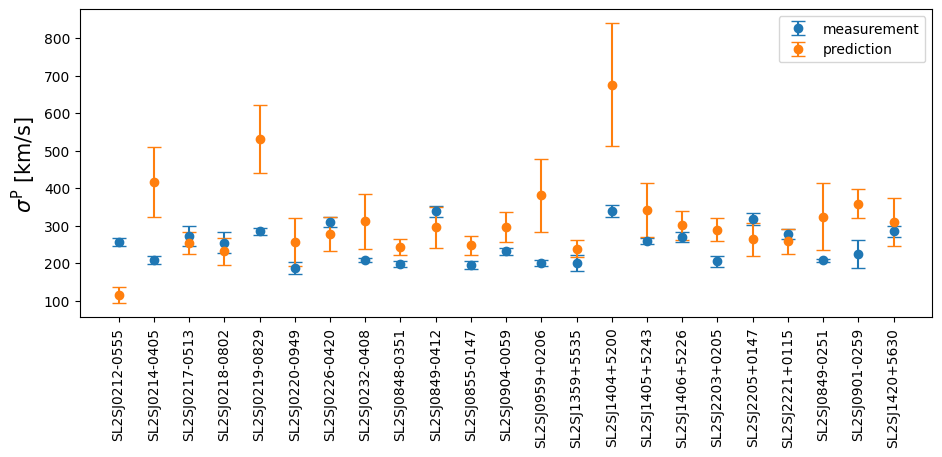

In [8]:
# load ifu files
file_name_slit_all = os.path.splitext(file_name_slit)[0] + '_all.pkl'
file = open(file_name_slit_all, 'rb')
sl2s_likelihood_processed = pickle.load(file)
file.close()


for kwargs_likelihood in sl2s_likelihood_processed:
    try:
        del kwargs_likelihood['flag_imaging']
    except:
        pass

from hierarc.Diagnostics.goodness_of_fit import GoodnessOfFit
from astropy.cosmology import FlatLambdaCDM


kwargs_cosmo = {'h0': 70, 'om': 0.30}
kwargs_lens = {'lambda_mst': 1., 'lambda_mst_sigma': 0.1}
kwargs_kin = {'a_ani': 1, "a_ani_sigma": 0.1}

cosmo = FlatLambdaCDM(H0=kwargs_cosmo['h0'], Om0=kwargs_cosmo['om'])

kwargs_model = {"lambda_mst_sampling": True,
                "lambda_mst_distribution": "GAUSSIAN",
                "anisotropy_model": anisotropy_model,
                "anisotropy_sampling": True,
                "anisotropy_distribution": "GAUSSIAN"}
gof = GoodnessOfFit(sl2s_likelihood_processed, kwargs_model=kwargs_model)
red_chi2 = gof.reduced_chi2(cosmo, kwargs_lens, kwargs_kin)
print(red_chi2, 'reduced chi2')

f, ax = gof.plot_kin_fit(cosmo, kwargs_lens, kwargs_kin, kwargs_los={}, color_measurement=None, color_prediction=None)
f.show()
